In [1]:
using LowLevelFEM, LinearAlgebra, Plots

In [2]:
structured_rect_mesh(n=10)

mat = Material("body")
prob = Problem([mat], type=:PlaneStress)

Problem("structured_rect", :PlaneStress, 2, 2, Material[Material("body", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 121, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, nothing), :u, :f)

In [3]:
K = stiffnessMatrix(prob)
M = massMatrix(prob);

In [4]:
u0 = initialDisplacement(prob, "leftbottom", ux=0, uy=0)
v0 = initialVelocity(prob, "leftbottom", vx=1, vy=1)
initialVelocity!(v0, "righttop", vx=-1, vy=-1)
f = loadVector(prob, [])

nodal VectorField
[0.0; 0.0; … ; 0.0; 0.0;;]

In [5]:
T = smallestPeriodTime(K, M)

5.921585807557995e-8

In [6]:
u, v = CDM(K, M, f, u0, v0, 1000, T / 10π)

(VectorField(Matrix{Float64}[], [0.0 1.8848993044313357e-9 … -1.4070179365471168e-10 -1.8544753011663722e-10; 0.0 1.8848993044313357e-9 … -1.4070179365504279e-10 -1.8544753011697102e-10; … ; 0.0 0.0 … 9.567634487383004e-11 1.5172097883363485e-10; 0.0 0.0 … 9.567634487405973e-11 1.5172097883386462e-10], [0.0, 1.8848993044313357e-9, 3.7697986088626715e-9, 5.654697913294007e-9, 7.539597217725343e-9, 9.424496522156678e-9, 1.1309395826588014e-8, 1.3194295131019351e-8, 1.5079194435450686e-8, 1.696409373988202e-8  …  1.8660503113870224e-6, 1.8679352106914537e-6, 1.869820109995885e-6, 1.8717050093003165e-6, 1.8735899086047478e-6, 1.875474807909179e-6, 1.8773597072136103e-6, 1.8792446065180417e-6, 1.881129505822473e-6, 1.8830144051269045e-6], Int64[], 1000, :v2D, Problem("structured_rect", :PlaneStress, 2, 2, Material[Material("body", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 121, LowLevelFEM.Geometry

In [7]:
showDoFResults(u, name="u")
showDoFResults(v, name="v")

1

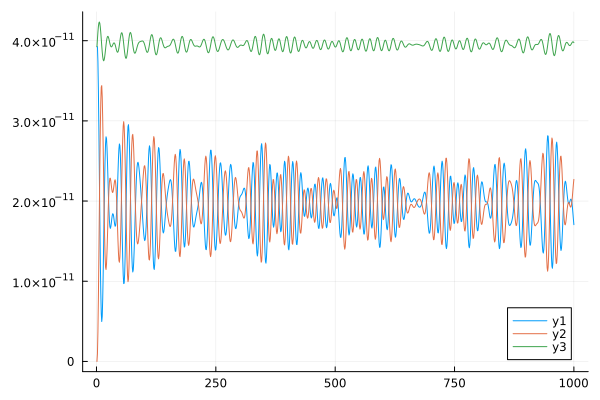

In [8]:
kene = v * M * v / 2
sene = u * K * u / 2

plot(kene)
plot!(sene)
plot!(kene + sene)

In [9]:
ε = solveStrain(u)
σ = solveStress(u)

e = σ ⋅ ε

showDoFResults(e, name="energy density")

2

In [10]:
s = σ * expandTo3D(v)
s = elementsToNodes(s)
s = projectTo2D(s)

showDoFResults(s, name="energy flow")
#s = nodesToElements(expandTo3D(v))

3

In [11]:
#projectTo2D(s)

In [12]:
openPostProcessor()

XOpenIM() failed
Fontconfig warning: using without calling FcInit()
